<a href="https://colab.research.google.com/github/MtBalbine/PROJETO-1---ESTATISTICA-E-ANALISE-DE-DADOS/blob/main/VarQuantitativaCir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

Definição de arquivo

In [28]:
arquivo = 'economia_circular.xlsx'
coluna = 'Taxa_Circularidade_percent'

Leitura de Planilha

In [29]:
df=pd.read_excel(arquivo)
df

,Setor,Porte,Tipo_Separador,Eficiencia_Mecanica_percent,Elevadores_Capacidade_ton_h,Nivel_Automacao_percent,Motor_Alta_Eficiencia,Consumo_Energetico_kWh_mes,Materia_Prima_Reciclada_ton_mes,Agua_Consumida_m3_mes,Residuos_Aterro_ton_mes,Taxa_Circularidade_percent,Emissoes_CO2_ton_mes,Economia_Reciclagem_R$_mes,Indice_Sustentabilidade
0,Alimentos,Pequeno,Densidade,88.0,97.1,37.5,Não,25444,29.5,456.4,8.8,21.2,9.2,18200,27.2
1,Plásticos,Médio,Eletrostático,73.5,27.0,69.5,Não,178027,91.4,240.8,8.0,67.5,0.1,58780,69.7
2,Têxtil,Médio,Densidade,75.3,27.9,59.2,Não,116287,40.2,267.1,13.3,37.4,41.2,32100,56.4
3,Eletrônicos,Médio,Magnético,90.5,47.8,47.7,Parcial,167413,108.7,450.1,19.7,44.5,15.9,72840,52.7
4,Metalurgia,Médio,Densidade,78.1,98.4,41.2,Sim,145441,70.3,314.5,11.5,29.5,284.3,43080,38.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,Alimentos,Médio,Densidade,94.5,40.7,69.4,Não,109477,59.6,1661.3,29.0,34.3,26.7,40640,48.8
274,Têxtil,Médio,Magnético,74.1,30.0,45.0,Sim,63630,6.6,255.7,7.2,30.5,78.1,7540,48.5
275,Química,Pequeno,Óptico,87.5,16.1,32.9,Não,33317,17.6,526.1,4.0,32.1,97.8,12680,46.6
276,Eletrônicos,Pequeno,Eletrostático,84.6,27.4,47.1,Sim,31395,13.8,69.7,1.4,47.1,2.8,9140,57.4


Extremidades da tabela

In [30]:
valormin=df[coluna].min()
valormax=df[coluna].max()
print (valormin,valormax)

10.5 100.0


Definição de Classes


In [31]:
classes = [10,20,30,40,50,60,70,80,90,100]
frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))
frequencia.sort_index(ascending=True)

/tmp/ipykernel_1647/2838193740.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))


,count
Taxa_Circularidade_percent,
"[10, 20)",24
"[20, 30)",61
"[30, 40)",78
"[40, 50)",36
"[50, 60)",25
"[60, 70)",16
"[70, 80)",14
"[80, 90)",7
"[90, 100)",8


Frequência Relativa

In [32]:
Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)
Freqpercentual.sort_index(ascending=True)

/tmp/ipykernel_1647/2202019940.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)


,proportion
Taxa_Circularidade_percent,
"[10, 20)",8.92
"[20, 30)",22.68
"[30, 40)",29.00
"[40, 50)",13.38
"[50, 60)",9.29
"[60, 70)",5.95
"[70, 80)",5.20
"[80, 90)",2.60
"[90, 100)",2.97


Colunas de frequência acumulada e de frequência relativa acumulada


In [33]:
#note que é necessário acumular a coluna da frequência com as classes ordenadas, isto é, usando sort_index
freqacum=np.cumsum(frequencia.sort_index())
freqacum




,count
Taxa_Circularidade_percent,
"[10, 20)",24
"[20, 30)",85
"[30, 40)",163
"[40, 50)",199
"[50, 60)",224
"[60, 70)",240
"[70, 80)",254
"[80, 90)",261
"[90, 100)",269


In [34]:
freqpercacum=np.cumsum(Freqpercentual.sort_index())
freqpercacum

,proportion
Taxa_Circularidade_percent,
"[10, 20)",8.92
"[20, 30)",31.60
"[30, 40)",60.60
"[40, 50)",73.98
"[50, 60)",83.27
"[60, 70)",89.22
"[70, 80)",94.42
"[80, 90)",97.02
"[90, 100)",99.99


 Tabela Geral

In [35]:
dist_freq = pd.DataFrame({'Frequência': frequencia,'Frequência Relativa (%)':Freqpercentual,'Frequência Acumulativa': freqacum,'Frequência Relativa Acumulativa (%)':freqpercacum})
display(dist_freq)
print(f'\n      Variável:{coluna}')
print('     *Limites superiores do intervalo de classes não incluídos')

,Frequência,Frequência Relativa (%),Frequência Acumulativa,Frequência Relativa Acumulativa (%)
Taxa_Circularidade_percent,,,,
"[10, 20)",24,8.92,24,8.92
"[20, 30)",61,22.68,85,31.60
"[30, 40)",78,29.00,163,60.60
"[40, 50)",36,13.38,199,73.98
"[50, 60)",25,9.29,224,83.27
"[60, 70)",16,5.95,240,89.22
"[70, 80)",14,5.20,254,94.42
"[80, 90)",7,2.60,261,97.02
"[90, 100)",8,2.97,269,99.99



      Variável:Taxa_Circularidade_percent
     *Limites superiores do intervalo de classes não incluídos


Histograma da Taxa de Circularidade


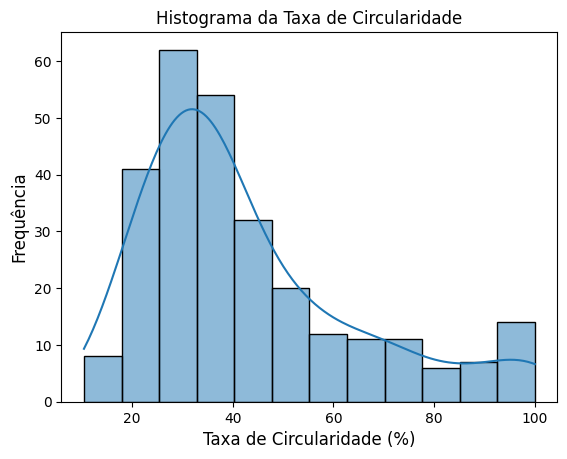

In [36]:
sns.histplot(data=df,x="Taxa_Circularidade_percent",kde=True)
plt.ylabel("Frequência",size=12)
plt.xlabel("Taxa de Circularidade (%)",size=12)
plt.title('Histograma da Taxa de Circularidade') # Adiciona o título aqui
plt.show()

Calculo da méda, moda e mediana:

In [37]:
#cálculo da Média.
df.Taxa_Circularidade_percent.mean()

np.float64(42.92122302158273)

In [38]:
# cálculo da moda.
df.Taxa_Circularidade_percent.mode()

,Taxa_Circularidade_percent
0,100.0


In [39]:
#cálculo da mediana.
df.Taxa_Circularidade_percent.median()

36.5